In [223]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer, StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [224]:
df = pd.read_csv(r'data\cleaned\smartphones_cleaned.csv')

In [225]:
pd.set_option('display.max_columns', None)

In [226]:
df.isna().sum()

category                      0
name_card                   312
price                         0
price_old                     0
price_installment             0
rating_card                   0
reviews_card                  0
name_seller                   0
rating_seller                 0
article                       9
screen_diagonal               0
battery_capacity              0
cpu                           0
screen_size                   0
processor_cores               0
ram                           0
built-in_memory               0
main_camera                   0
os                            0
hz_screen                     0
matrix                        0
processor_brand               0
ghz_processor                 0
e_sim                         0
front_camera                  0
type_of_frame                 0
degree_of_protect             0
dimensions                    0
weight_g                      0
country_of_origin             0
case_material                 0
brand_gr

In [227]:
df.dropna(inplace=True)

In [228]:
df.head()

,category,name_card,price,price_old,price_installment,rating_card,reviews_card,name_seller,rating_seller,article,screen_diagonal,battery_capacity,cpu,screen_size,processor_cores,ram,built-in_memory,main_camera,os,hz_screen,matrix,processor_brand,ghz_processor,e_sim,front_camera,type_of_frame,degree_of_protect,dimensions,weight_g,country_of_origin,case_material,brand_graphic_proccessor,video_processor,max_fps_video,discount_abs,discount_pct,cpu_power_proxy,memory_per_price,ram_per_price,total_camera_mp,selfie_ratio,battery_per_gram,high_fps_video,esim_flag,protection_flag,res_w,res_h,pixel_count
0,smartphones,Xiaomi Смартфон Xiaomi Redmi Note 14 Pro+ 5G Р...,216456.0,542517.0,18038.0,4.8,322.0,SmartPhone,4.9,3.469361e+09,6.67,5110.0,Snapdragon 7s Gen3,2712x1220,8.0,8.0,256.0,200.0,Android,120.0,AMOLED,Qualcomm,2.5,eSIM+SIM,20.0,Моноблок,IP68,162.53х74.67х8.85,205.13,Китай,no_data,no_data,no_data,60.0,326061.0,60.101527,20.0,0.001183,0.000037,220.0,0.100000,24.911032,1,0,1,2712.0,1220.0,3308640.0
1,smartphones,"Смартфон A16 Pro Ростест (EAC) 16/1 ТБ, серый",54016.0,440665.0,4502.0,5.0,29.0,AMG,4.5,3.689839e+09,6.80,8000.0,Dimensity 9300 Plus,3200x2400,10.0,16.0,1024.0,108.0,Android,90.0,IPS,MediaTek,3.4,SIM (без eSIM),50.0,Моноблок,IP45,155*74*8.4,200.00,Китай,"Стекло, Металл",Qualcomm,Adreno 730,60.0,386649.0,87.742162,34.0,0.018957,0.000296,158.0,0.462963,40.000000,1,0,1,3200.0,2400.0,7680000.0
3,smartphones,"Xiaomi Смартфон Mix Flip 12/512 ГБ, фиолетовый",61762.0,322025.0,46191.0,4.7,9.0,Teleflow,4.9,3.323519e+09,6.86,4780.0,Snapdragon 8 Gen3,2700x1224,8.0,12.0,512.0,50.0,Android,120.0,AMOLED,Qualcomm,3.3,SIM (без eSIM),32.0,Складной,IP68,167.5x74x7.6,192.00,Китай,"Металл, Стекло",Qualcomm,Adreno 750,60.0,260263.0,80.820744,26.4,0.008290,0.000194,82.0,0.640000,24.895833,1,0,1,2700.0,1224.0,3304800.0
4,smartphones,"Redmi Смартфон Redmi 14C Global 8/256 ГБ, сире...",61762.0,322025.0,4901.0,4.3,63.0,opt. marina,4.3,2.396422e+09,6.88,5160.0,Helio G81,1640x720,8.0,8.0,256.0,50.0,Android,120.0,no_data,MediaTek,2.0,SIM (без eSIM),13.0,Моноблок,IP68,171.88*77.8*8.22,211.00,Китай,"Металл, Стекло",no_data,no_data,30.0,260263.0,80.820744,16.0,0.004145,0.000130,63.0,0.260000,24.454976,0,0,1,1640.0,720.0,1180800.0
5,smartphones,"INOI Смартфон A75 Elegance 6/256 ГБ, черный",38625.0,381979.0,3219.0,4.8,80.0,Buyon,4.8,2.576112e+09,6.78,6000.0,no_data,no_data,8.0,6.0,256.0,50.0,no_data,120.0,no_data,no_data,2.4,no_data,16.0,no_data,no_data,no_data,200.00,no_data,no_data,no_data,no_data,60.0,343354.0,89.888188,19.2,0.006628,0.000155,66.0,0.320000,30.000000,1,0,0,2392.0,1080.0,2592000.0


In [229]:
df['name_seller'].value_counts()

name_seller
Ozon Россия       434
AppClinic          70
SmartPhone         62
Appel              59
МСота              54
                 ... 
Varik               1
Яюань Торговля      1
ROCKET              1
ТекБридж            1
Zhoujia             1
Name: count, Length: 445, dtype: int64

In [230]:
counts = df['name_seller'].value_counts()
seller_size_map = pd.qcut(counts, q=3, labels=['Small', 'Medium', 'Large']).to_dict()
df['seller_category'] = df['name_seller'].map(seller_size_map)
print(df['seller_category'].value_counts())

seller_category
Large     3836
Medium     924
Small      303
Name: count, dtype: int64


In [231]:
X = df.drop(columns=['price'])
y = df['price']

In [232]:
numerical = X.select_dtypes(include=np.number).columns

test = df[numerical].dropna()
X_const = add_constant(test)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_result)

c:\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


              feature        VIF
12        main_camera        inf
15       front_camera        inf
23    total_camera_mp        inf
1           price_old  86.069848
20    cpu_power_proxy  76.170720
18       discount_abs  72.179847
14      ghz_processor  46.436865
21   memory_per_price  36.096367
31        pixel_count  20.357913
9     processor_cores  18.518366
22      ram_per_price  16.852843
11    built-in_memory  16.688613
30              res_h   8.436380
29              res_w   7.571526
16           weight_g   5.794356
25   battery_per_gram   5.641938
8    battery_capacity   5.421475
10                ram   4.987363
2   price_installment   4.830619
19       discount_pct   2.530906
5       rating_seller   1.833380
7     screen_diagonal   1.647495
24       selfie_ratio   1.484652
6             article   1.433753
3         rating_card   1.429101
26     high_fps_video   1.358216
28    protection_flag   1.260371
13          hz_screen   1.231794
4        reviews_card   1.183769
17      ma

In [233]:
X = X.drop(columns=['total_camera_mp','price_old','cpu_power_proxy','memory_per_price','article','pixel_count', 'name_seller'])

In [234]:
numerical = X.select_dtypes(include=np.number).columns

test = df[numerical].dropna()
X_const = add_constant(test)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]

vif_result = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_result)

              feature       VIF
14           weight_g  5.663950
20   battery_per_gram  5.470154
6    battery_capacity  5.387002
13       front_camera  4.723342
9     built-in_memory  4.461532
8                 ram  4.310789
12      ghz_processor  2.679708
1   price_installment  2.575551
10        main_camera  2.372412
24              res_w  2.249718
16       discount_abs  1.903614
17       discount_pct  1.799674
25              res_h  1.782089
4       rating_seller  1.781906
5     screen_diagonal  1.601765
19       selfie_ratio  1.466643
2         rating_card  1.421242
21     high_fps_video  1.346904
7     processor_cores  1.340942
23    protection_flag  1.247681
11          hz_screen  1.197155
3        reviews_card  1.148143
15      max_fps_video  1.124988
18      ram_per_price  1.120509
22          esim_flag       NaN


c:\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [235]:
X.head()

,category,name_card,price_installment,rating_card,reviews_card,rating_seller,screen_diagonal,battery_capacity,cpu,screen_size,processor_cores,ram,built-in_memory,main_camera,os,hz_screen,matrix,processor_brand,ghz_processor,e_sim,front_camera,type_of_frame,degree_of_protect,dimensions,weight_g,country_of_origin,case_material,brand_graphic_proccessor,video_processor,max_fps_video,discount_abs,discount_pct,ram_per_price,selfie_ratio,battery_per_gram,high_fps_video,esim_flag,protection_flag,res_w,res_h,seller_category
0,smartphones,Xiaomi Смартфон Xiaomi Redmi Note 14 Pro+ 5G Р...,18038.0,4.8,322.0,4.9,6.67,5110.0,Snapdragon 7s Gen3,2712x1220,8.0,8.0,256.0,200.0,Android,120.0,AMOLED,Qualcomm,2.5,eSIM+SIM,20.0,Моноблок,IP68,162.53х74.67х8.85,205.13,Китай,no_data,no_data,no_data,60.0,326061.0,60.101527,0.000037,0.100000,24.911032,1,0,1,2712.0,1220.0,Large
1,smartphones,"Смартфон A16 Pro Ростест (EAC) 16/1 ТБ, серый",4502.0,5.0,29.0,4.5,6.80,8000.0,Dimensity 9300 Plus,3200x2400,10.0,16.0,1024.0,108.0,Android,90.0,IPS,MediaTek,3.4,SIM (без eSIM),50.0,Моноблок,IP45,155*74*8.4,200.00,Китай,"Стекло, Металл",Qualcomm,Adreno 730,60.0,386649.0,87.742162,0.000296,0.462963,40.000000,1,0,1,3200.0,2400.0,Medium
3,smartphones,"Xiaomi Смартфон Mix Flip 12/512 ГБ, фиолетовый",46191.0,4.7,9.0,4.9,6.86,4780.0,Snapdragon 8 Gen3,2700x1224,8.0,12.0,512.0,50.0,Android,120.0,AMOLED,Qualcomm,3.3,SIM (без eSIM),32.0,Складной,IP68,167.5x74x7.6,192.00,Китай,"Металл, Стекло",Qualcomm,Adreno 750,60.0,260263.0,80.820744,0.000194,0.640000,24.895833,1,0,1,2700.0,1224.0,Small
4,smartphones,"Redmi Смартфон Redmi 14C Global 8/256 ГБ, сире...",4901.0,4.3,63.0,4.3,6.88,5160.0,Helio G81,1640x720,8.0,8.0,256.0,50.0,Android,120.0,no_data,MediaTek,2.0,SIM (без eSIM),13.0,Моноблок,IP68,171.88*77.8*8.22,211.00,Китай,"Металл, Стекло",no_data,no_data,30.0,260263.0,80.820744,0.000130,0.260000,24.454976,0,0,1,1640.0,720.0,Large
5,smartphones,"INOI Смартфон A75 Elegance 6/256 ГБ, черный",3219.0,4.8,80.0,4.8,6.78,6000.0,no_data,no_data,8.0,6.0,256.0,50.0,no_data,120.0,no_data,no_data,2.4,no_data,16.0,no_data,no_data,no_data,200.00,no_data,no_data,no_data,no_data,60.0,343354.0,89.888188,0.000155,0.320000,30.000000,1,0,0,2392.0,1080.0,Large


In [236]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [237]:
norm = df[numerical].drop(columns=['price_installment', 'battery_capacity','discount_abs']).columns.to_list()

In [238]:
huge_feat_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('huge', huge_feat_pipe, ['price_installment', 'battery_capacity','discount_abs']),
    ('norm', StandardScaler(), norm),
    ('OHE', OneHotEncoder(handle_unknown='ignore'), ['os', 'processor_brand', 'e_sim', 'seller_category', 'type_of_frame', 'brand_graphic_proccessor', ])
])

In [239]:
target_pipe = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), ['price'])
])

In [240]:
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [241]:
param_dist = {
    'model__alpha': loguniform(1e-3, 1e3),
    'model__fit_intercept': [True, False],
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
}

In [242]:
ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [243]:
ridge_search.fit(X_train, target_pipe.fit_transform(y_train.to_frame()).ravel())

Fitting 5 folds for each of 50 candidates, totalling 250 fits

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__alpha': <scipy.stats....001B4E10CE480>, 'model__fit_intercept': [True, False], 'model__solver': ['auto', 'svd', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that 

In [244]:
print("Best params:", ridge_search.best_params_)
print("Best RMSE:", -ridge_search.best_score_)

Best params: {'model__alpha': np.float64(1.40779231399724), 'model__fit_intercept': False, 'model__solver': 'auto'}
Best RMSE: 0.19531411726196052


In [245]:
best_ridge = ridge_search.best_estimator_

In [246]:
y_pred = best_ridge.predict(X_test)
y_pred_exp = np.expm1(y_pred)

In [247]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_exp)))
print("Test R^2:", r2_score(y_test, y_pred_exp))

Test RMSE: 14488.710479244546
Test R^2: 0.9860334311395924


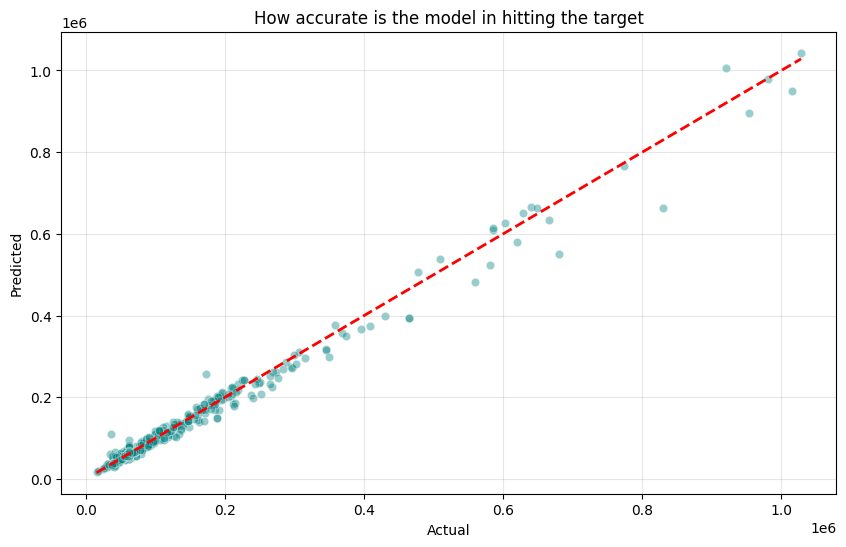

In [248]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_exp, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('How accurate is the model in hitting the target')
plt.grid(True, alpha=0.3)
plt.show()

In [249]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_exp,
    'error_pct': np.abs(y_test - y_pred_exp) / y_test * 100
})
print(results_df.nlargest(10, 'error_pct'))

        actual      predicted   error_pct
1301   35324.0  109883.082402  211.072026
2430   35031.0   61678.690334   76.068883
4312   42378.0   66110.032632   56.000832
5148   61762.0   94995.685343   53.809276
4290   37037.0   55286.857673   49.274665
1513  172538.0  257423.724190   49.198278
718    38479.0   56421.846826   46.630232
4814   42342.0   56854.289990   34.273983
2141   61762.0   82622.507271   33.775634
4516   40862.0   54358.556194   33.029603


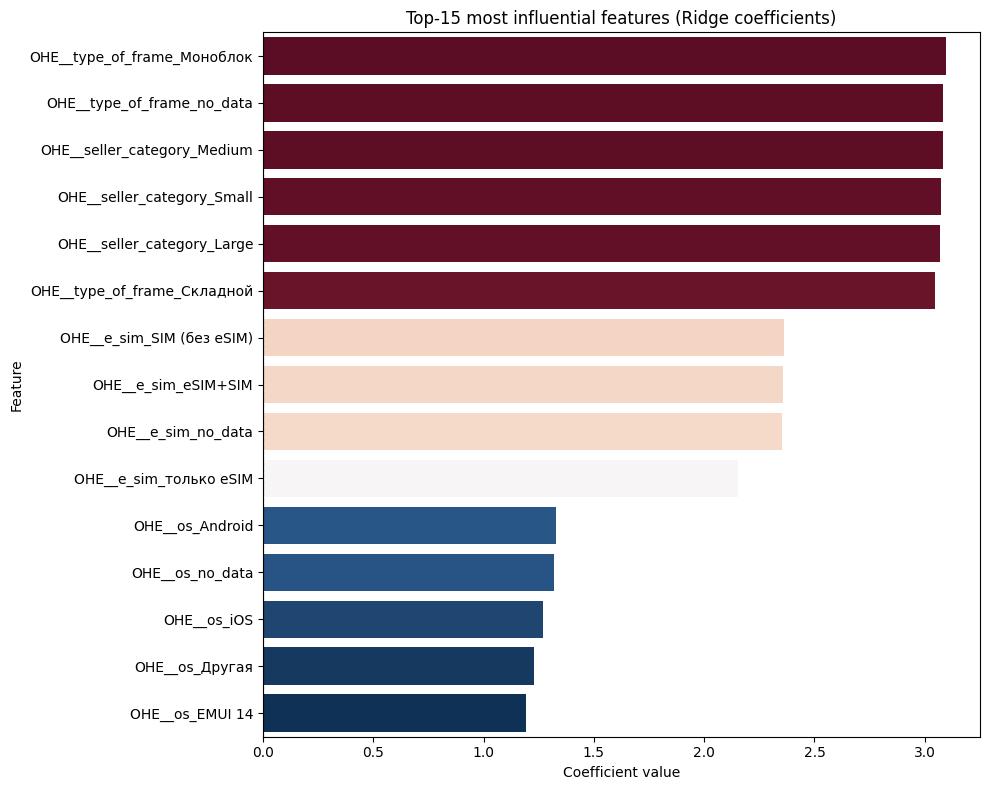

In [250]:
feature_names = best_ridge.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_ridge.named_steps['model'].coef_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='coefficient',
    y='feature',
    data=feat_imp_df.head(15),
    palette='RdBu_r',
    hue='coefficient',
    legend=False
)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top-15 most influential features (Ridge coefficients)')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()